In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor

In [ ]:
df = pd.read_csv('C:\\Users\\Admin\\OneDrive\\Desktop\\data science\\ML\\SUPERVISED LEARNING\\Dataset\\employee_attrition_dataset.csv')
X = df.drop(columns='Attrition')
y =  df.Attrition
df.head(4)

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'Employee_ID'),
  Text(1, 0, 'Age'),
  Text(2, 0, 'Job_Level'),
  Text(3, 0, 'Monthly_Income'),
  Text(4, 0, 'Hourly_Rate'),
  Text(5, 0, 'Years_at_Company'),
  Text(6, 0, 'Years_in_Current_Role'),
  Text(7, 0, 'Years_Since_Last_Promotion'),
  Text(8, 0, 'Work_Life_Balance'),
  Text(9, 0, 'Job_Satisfaction'),
  Text(10, 0, 'Performance_Rating'),
  Text(11, 0, 'Training_Hours_Last_Year'),
  Text(12, 0, 'Project_Count'),
  Text(13, 0, 'Average_Hours_Worked_Per_Week'),
  Text(14, 0, 'Absenteeism'),
  Text(15, 0, 'Work_Environment_Satisfaction'),
  Text(16, 0, 'Relationship_with_Manager'),
  Text(17, 0, 'Job_Involvement'),
  Text(18, 0, 'Distance_From_Home'),
  Text(19, 0, 'Number_of_Companies_Worked')])

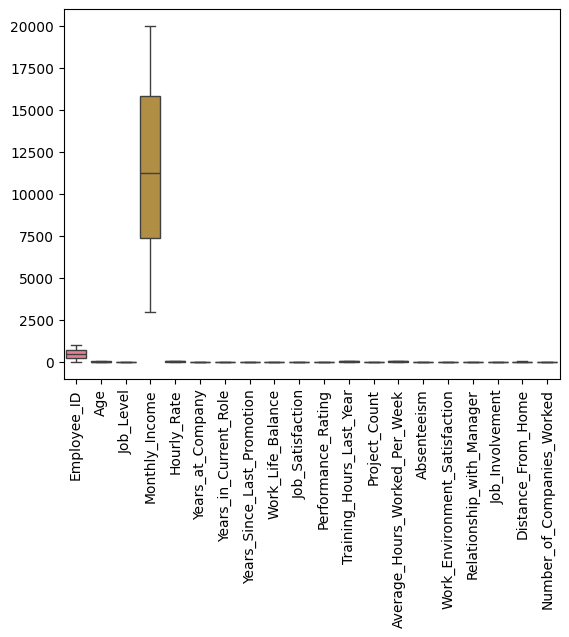

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df)
plt.xticks(rotation=90)

In [60]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y,train_size=0.8,random_state=42)

In [61]:
num_cols = X.select_dtypes(include="number").columns
obj_cols = X.select_dtypes(exclude='number').columns

In [62]:
preprocessing = ColumnTransformer(
    transformers=[
        ('encoder',OneHotEncoder(),obj_cols),
        ('scaling',MinMaxScaler(),num_cols)
    ]
)
main_pipe = Pipeline(
    steps=[
        ('pre',preprocessing),
        ('model',RandomForestClassifier())
    ]
)
main_pipe.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoder', ...), ('scaling', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [63]:
ytrain_pred = main_pipe.predict(xtrain)

In [64]:
confusion_matrix(ytrain,ytrain_pred)

array([[642,   0],
       [  0, 158]])

In [65]:
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00       642
         Yes       1.00      1.00      1.00       158

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



In [66]:
ytest_pred = main_pipe.predict(xtest)
confusion_matrix(ytest,ytest_pred)

array([[169,   0],
       [ 31,   0]])

In [67]:
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

          No       0.84      1.00      0.92       169
         Yes       0.00      0.00      0.00        31

    accuracy                           0.84       200
   macro avg       0.42      0.50      0.46       200
weighted avg       0.71      0.84      0.77       200



c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave